In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Loading the Pima Indians Diabetes database
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Task 1

In [43]:
import numpy as np
cols_with_hidden_na = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Data Quality Issue: Zeros found in medical columns:")
print((df[cols_with_hidden_na] == 0).sum())

Data Quality Issue: Zeros found in medical columns:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Task 2

In [11]:
cols_with_hidden_na = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_hidden_na] = df[cols_with_hidden_na].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Task 3

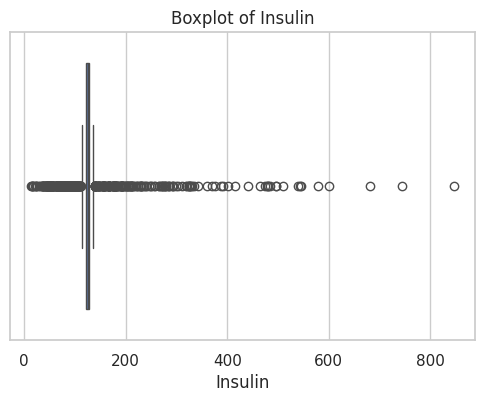

df with outliers:  (768, 9)
df without outliers:  (422, 9)


In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Insulin'])
plt.title('Boxplot of Insulin')
plt.show()

Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)

## Task 4

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_no_outliers[['Glucose', 'BMI']].copy()
df_scaled[['Glucose', 'BMI']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Glucose,BMI
0,0.670968,0.314928
1,0.264516,0.171779
2,0.896774,0.104294
5,0.464516,0.151329
7,0.458065,0.349693


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_no_outliers[['Glucose', 'BMI']].copy()
df_standardized[['Glucose', 'BMI']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Glucose,BMI
0,0.896717,0.239299
1,-1.224290,-0.793561
2,2.075055,-1.280480
5,-0.180620,-0.941112
7,-0.214287,0.490136


## Task 5

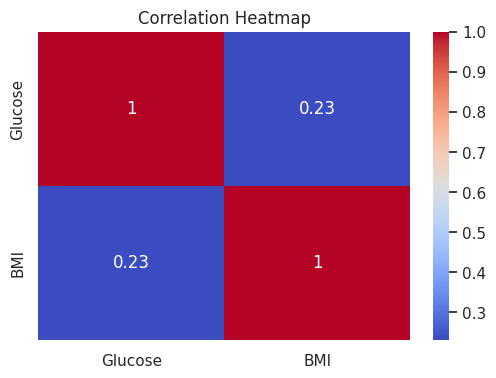

Explained Variance Ratio: [0.61568022]


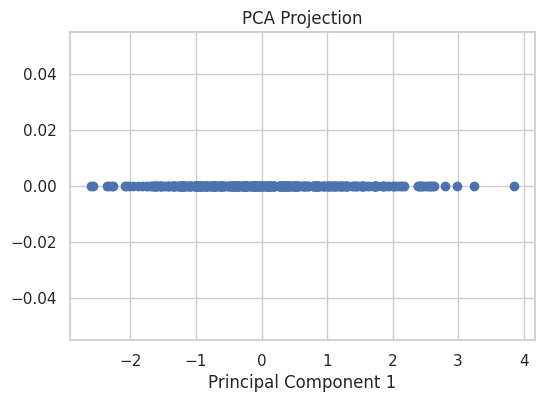

In [15]:
# Check Correlation Before Applying PCA
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Glucose', 'BMI']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

from sklearn.decomposition import PCA

X = df_standardized[['Glucose', 'BMI']]
pca = PCA(n_components=1) # Reduce 2 features to 1 Component
principal_component = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.scatter(principal_component, np.zeros_like(principal_component))
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.show()